## Автоэнкодер и их типы

In [3]:
from keras.datasets import mnist
from keras.layers import Conv2D
import numpy as np

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test  = x_test .astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test  = np.reshape(x_test,  (len(x_test),  28, 28, 1))

### Сжимающий автоэнкодер

Для начала создадим наиболее простой (сжимающий, undercomplete) автоэнкодер с кодом малой размерности из двух полносвязных слоев: енкодера и декодера.

Так как интенсивность цвета нормирована на единицу, то активацию выходного слоя возьмем сигмоидой.

Напишем отдельные модели для энкодера, декодера и целого автоэнкодера. Для этого создадим экземпляры слоев и применим их один за другим, в конце все объединив в модели.

In [4]:
from keras.layers import Input, Dense, Flatten, Reshape
from keras.models import Model

def create_dense_ae():
    # Размерность скрытого пространства
    encoding_dim = 49
    
    # Правило связывания слоев:
    # первая скобка - параметры текущего слоя
    # вторая скобка - переменная, которая отвечает за предыдущий слой

    # Энкодер
    # Входной слой
    # 28, 28, 1 - размерности строк, столбцов, фильтров одной картинки
    input_img = Input(shape=(28, 28, 1)) 
    # Вспомогательный слой    
    middle_img=Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', input_shape=(28, 28, 1))(input_img)
    # Кодированное полносвязным слоем представление
    flat_img = Flatten()(middle_img)
    
    encoded=Dense(encoding_dim, activation='relu')(flat_img)
    
    # Декодер
    # Раскодированное другим полносвязным слоем изображение
    input_encoded = Input(shape=(encoding_dim,))
    flat_decoded = Dense(28*28, activation='sigmoid')(input_encoded)
    decoded = Reshape((28, 28, 1))(flat_decoded)

    # Модели: в конструктор первым аргументом передаются входные слои, а вторым выходные слои
    encoder=Model(input_img, encoded, name="encoder")
    decoder = Model(input_encoded, decoded, name="decoder")
    autoencoder = Model(input_img, decoder(encoder(input_img)), name="autoencoder")
    return encoder, decoder, autoencoder

Создадим и скомпилируем модель (под компиляцией в данном случае понимается построение графа вычислений обратного распространения ошибки)

In [5]:
encoder, decoder, autoencoder = create_dense_ae()
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

D:\programming\python\projects\2025-NN-AI\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Посмотрим на число параметров

In [7]:
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 49)             │     1,060,017 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,060,337 (4.04 MB)

 Trainable params: 1,060,337 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 49)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │        39,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,200 (153.12 KB)

 Trainable params: 39,200 (153.12 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 49)             │     1,060,337 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │        39,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,099,537 (4.19 MB)

 Trainable params: 1,099,537 (4.19 MB)

 Non-trainable params: 0 (0.00 B)

Обучим теперь наш автоэнкодер

In [9]:
autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 0.2068 - val_loss: 0.1324
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.1208 - val_loss: 0.1104
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.1082 - val_loss: 0.1038
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.1035 - val_loss: 0.1006
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.1011 - val_loss: 0.0989
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.0998 - val_loss: 0.0980
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.0989 - val_loss: 0.0974
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.0983 - val_loss: 0.0968
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 0.0978 - val_loss: 0.0963
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.0975 - val_loss: 0.0960


Функция отрисовки цифр

In [11]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

def plot_digits(*args):
    args = [x.squeeze() for x in args]
    n = min([x.shape[0] for x in args])
    
    plt.figure(figsize=(2*n, 2*len(args)))
    for j in range(n):
        for i in range(len(args)):
            ax = plt.subplot(len(args), n, i*n + j + 1)
            plt.imshow(args[i][j])
            plt.gray()
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)

    plt.show()

Закодируем несколько изображений и взглянем на пример кода

In [12]:
n = 10

imgs = x_test[:n] # первые 10 картинок
encoded_imgs = encoder.predict(imgs, batch_size=n) # получить скрытые значения (вектор 49 чисел) для первых 10 картинок
encoded_imgs[0] # посмотреть на первую картинку (вектор значений)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


array([66.41985 , 59.365955, 32.214466, 39.642517,  0.      , 21.177334,
        0.      ,  0.      ,  0.      , 19.820894,  0.      , 30.654844,
        0.      , 17.610638, 53.417847,  0.      , 37.78875 ,  0.      ,
       60.188885, 53.923367,  0.      , 41.55362 , 20.874598, 29.508635,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      , 50.9623  ,
        0.      , 10.719377, 49.279816,  0.      , 13.951708, 20.945047,
       16.219412, 15.890958,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      , 24.299643,  0.      , 66.93703 ,
        0.      ], dtype=float32)

Декодируем эти коды и сравним с оригиналами

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


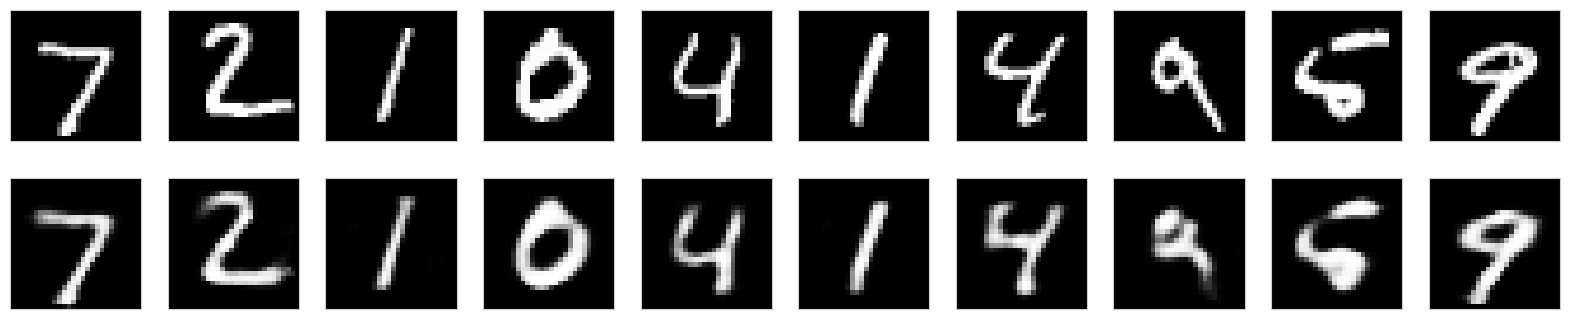

In [13]:
decoded_imgs = decoder.predict(encoded_imgs, batch_size=n)

plot_digits(imgs, decoded_imgs) # исходные и обработанные картинки

### Задания

С использованием приведенных сведений студентам надлежит:

* обучить на MNIST автокодировщик (мы провели обучение на 10 эпохах, попробовать другое значение, можно ли лучше?);
* получить векторы всех изображений MNIST с выхода кодера;
* использовать полученные векторы в качестве входных для обучения нейронной сети – классификатора рукописных цифр;
* сравнить точности классификации, получаемые нейронной сетью, обученными на изображениях MNIST и на векторах, снятых с выхода кодера автокодировщика.

In [ ]:
# Ваш код